# **EDA**

Alkmini Sapountzaki (alks@itu.dk), Caroline Sofie Skovby (cssk@itu.dk), Miriam Espinosa Solana (miri@itu.dk)



## Imports and Data Loading <a class="anchor" id="imports"></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import pearsonr


In [3]:
# Load the data 
df = pd.read_csv('data/recruitmentdataset-2022.csv')
df.head(10)

,Id,gender,age,nationality,sport,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,ind-degree,company,decision
0,x8011e,female,24,German,Swimming,70,False,False,False,False,1,True,phd,A,True
1,x6077a,male,26,German,Golf,67,False,True,False,False,2,True,bachelor,A,False
2,x6006e,female,23,Dutch,Running,67,False,True,True,False,0,True,master,A,False
3,x2173b,male,24,Dutch,Cricket,70,False,True,False,False,1,True,master,A,True
4,x6241a,female,26,German,Golf,59,False,False,False,False,1,False,master,A,True
5,x9063d,female,26,Dutch,Chess,63,False,False,False,False,1,True,bachelor,A,True
6,x5785d,female,27,Dutch,Tennis,63,True,True,False,False,2,True,bachelor,A,False
7,x8767c,female,22,Dutch,Swimming,71,False,True,False,False,1,True,master,A,True
8,x6541b,female,28,Dutch,Football,65,True,False,False,True,3,False,bachelor,A,False
9,x3890b,male,24,Dutch,Football,55,True,False,False,True,3,False,master,A,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Id                     4000 non-null   object
 1   gender                 4000 non-null   object
 2   age                    4000 non-null   int64 
 3   nationality            4000 non-null   object
 4   sport                  4000 non-null   object
 5   ind-university_grade   4000 non-null   int64 
 6   ind-debateclub         4000 non-null   bool  
 7   ind-programming_exp    4000 non-null   bool  
 8   ind-international_exp  4000 non-null   bool  
 9   ind-entrepeneur_exp    4000 non-null   bool  
 10  ind-languages          4000 non-null   int64 
 11  ind-exact_study        4000 non-null   bool  
 12  ind-degree             4000 non-null   object
 13  company                4000 non-null   object
 14  decision               4000 non-null   bool  
dtypes: bool(6), int64(3),

In [5]:
## One hot encode the categorical features
feature_names = [#'Id', # Id
                 "gender", # Gender - sensitive
                 'age', # age in years 
                 "nationality", # Nationality
                 'sport', # first/main sport listed on CV
                 'ind-university_grade', # University grade (percentage) of the canditate
                 "ind-debateclub", # whether candidate participated in debate club
                 "ind-programming_exp", # whether candidate has programming experience
                 'ind-international_exp', # whether candidate has international experience
                 "ind-entrepeneur_exp", # whether candidate has entrepeneur experience
                 "ind-languages", # Number of additional languages spoken fluently by candidate
                 'ind-exact_study', # whether candidate studied physics, engineering or other science-oriented study
                 'ind-degree', # highest completed degree. Phd, bachelor or master level
                 'company'] # The company the candidate applied to

target_name = "decision" # target value - wether the candidate got hired at the company or not

def data_processing(data, features, target_name:str):
    df = data
    ### Gender Filter
    df = df[df["gender"] != 'other'] # filter out 'other', to have binary gender

    ### Groups of interest
    sex = df["gender"].values

    ### Target
    df["target"] = df[target_name] # decision is target value
    target = df["target"].values

    #we want to keep df before one_hot encoding to make Bias Analysis - probably not relevant with decision being binary to begin with
    df = df[features + ["target", target_name]] 
    df_processed = df[features].copy()
    cols = [ "gender", "nationality", "sport", "ind-degree", "company"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=False)

    # drop the categories that are most represented in the data only if not data preprocessing
    df_processed_analysis = df_processed.drop(columns=["sport_Football", "gender_male", "nationality_Dutch", "ind-degree_bachelor", "company_A"])

    return df_processed, df_processed_analysis, df, target, sex

data_eda, data, data_original, target, group = data_processing(df, feature_names, target_name)

C:\Users\mespi\AppData\Local\Temp\ipykernel_23532\3406401853.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target"] = df[target_name] # decision is target value


## Explanatory Data Analysis (EDA) <a class="anchor" id="explanatory-analysis"></a>

### Distribution of the attributes

In [6]:
## Ignore the rows with other as gender 
df = df[df["gender"].str.lower() != "other"]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3917 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Id                     3917 non-null   object
 1   gender                 3917 non-null   object
 2   age                    3917 non-null   int64 
 3   nationality            3917 non-null   object
 4   sport                  3917 non-null   object
 5   ind-university_grade   3917 non-null   int64 
 6   ind-debateclub         3917 non-null   bool  
 7   ind-programming_exp    3917 non-null   bool  
 8   ind-international_exp  3917 non-null   bool  
 9   ind-entrepeneur_exp    3917 non-null   bool  
 10  ind-languages          3917 non-null   int64 
 11  ind-exact_study        3917 non-null   bool  
 12  ind-degree             3917 non-null   object
 13  company                3917 non-null   object
 14  decision               3917 non-null   bool  
dtypes: bool(6), int64(3), obje

#### Binary Variables

In [8]:
## Bar plot for binary variables
def make_barh(df, col, option_1, option_2, ax, title):

    ## Set colors 
    color_2 = "#53739E"
    color_1 = "#A59E9E"
    color_title = "#5E5F64"

    if col == "gender":
        keys, labels = [option_1, option_2], [option_1, option_2]
        counts = df[col].value_counts().reindex(keys, fill_value=0)
    else:
        keys, labels = [0, 1], [option_1, option_2]
        counts = df[col].astype(int).value_counts().reindex(keys, fill_value=0)

    pct = counts / counts.sum() * 100

    bar_height = 0.28

    ax.barh(y=0, width=pct[keys[0]], left=0, height=bar_height, color=color_1, edgecolor="white")
    ax.barh(y=0, width=pct[keys[1]], left=pct[keys[0]], height=bar_height, color=color_2, edgecolor="white")

    ax.text(pct[keys[0]] / 2, 0.32, f"{labels[0].capitalize()}\n{pct[keys[0]]:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color=color_1)
    ax.text(pct[keys[0]] + pct[keys[1]] / 2, 0.32, f"{labels[1].capitalize()}\n{pct[keys[1]]:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color=color_2)

    #ax.text(50, -0.28, title, ha="center", va="top", fontsize=13, color = color_title)
    #ax.set_title(title, fontsize=13, pad=20, color = color_title)
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.4, 0.9)
    ax.axis("off")

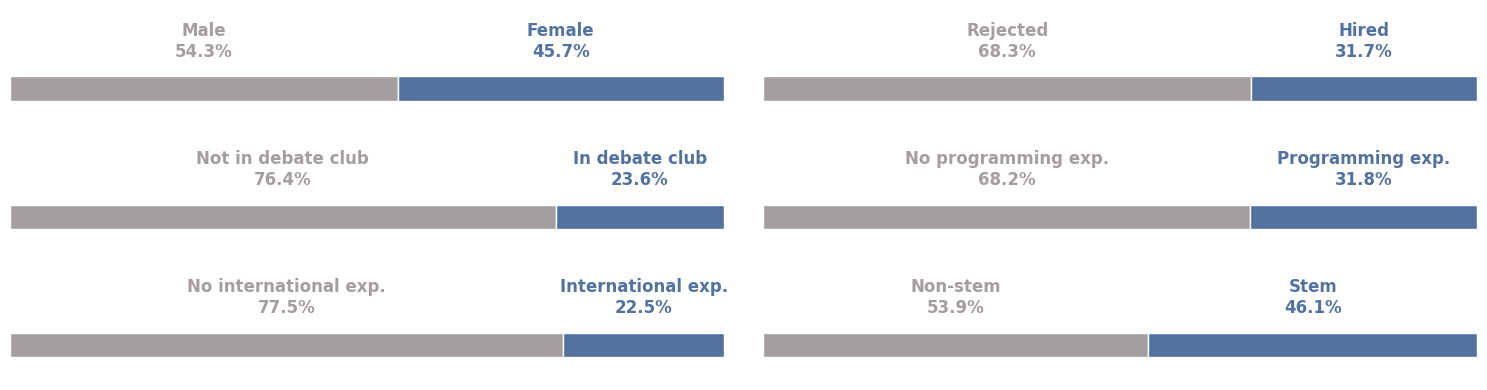

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4))
axes = axes.ravel()

colors = plt.get_cmap('Blues')(np.linspace(0.5, 0.9, 2))

make_barh(df, "gender", "male", "female", axes[0], "Gender Distribution")
make_barh(df, "decision", "Rejected", "Hired", axes[1], "Decision Distribution")
make_barh(df, "ind-debateclub", "Not in debate club", "In debate club", axes[2], "Debate Club Participation")
make_barh(df, "ind-programming_exp", "No programming exp.", "Programming exp.", axes[3], "Programming Experience")
make_barh(df, "ind-international_exp", "No international exp.", "International exp.", axes[4], "International Experience")
make_barh(df, "ind-exact_study", "Non-STEM", "STEM", axes[5], "STEM Background")

plt.tight_layout()
plt.show()

#### Continuous variables

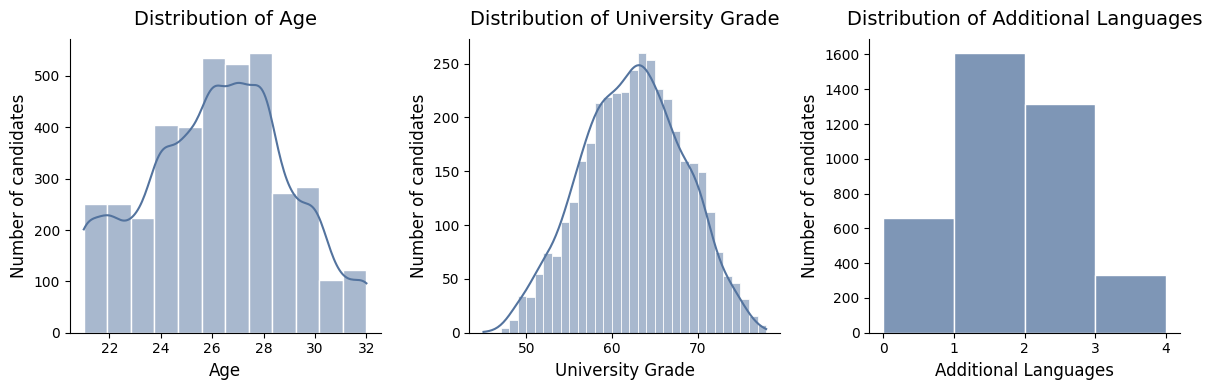

In [10]:

continuous_cols = {
    "age": "Age",
    "ind-university_grade": "University Grade", 
    "ind-languages": "Additional Languages"
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (col, title) in zip(axes, continuous_cols.items()):
    if col != "ind-languages":
        sns.histplot(data=df,x=col, bins=df[col].nunique(), kde=True, edgecolor="white", ax=ax, color="#53739E")
    else:
        sns.histplot(data=df,x=col, bins=range(df[col].min(), df[col].max() + 2), kde=False, edgecolor="white", ax=ax, color="#53739E")
    ax.set_title(f"Distribution of {title}", fontsize=14, pad=10)
    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel("Number of candidates", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical Variables

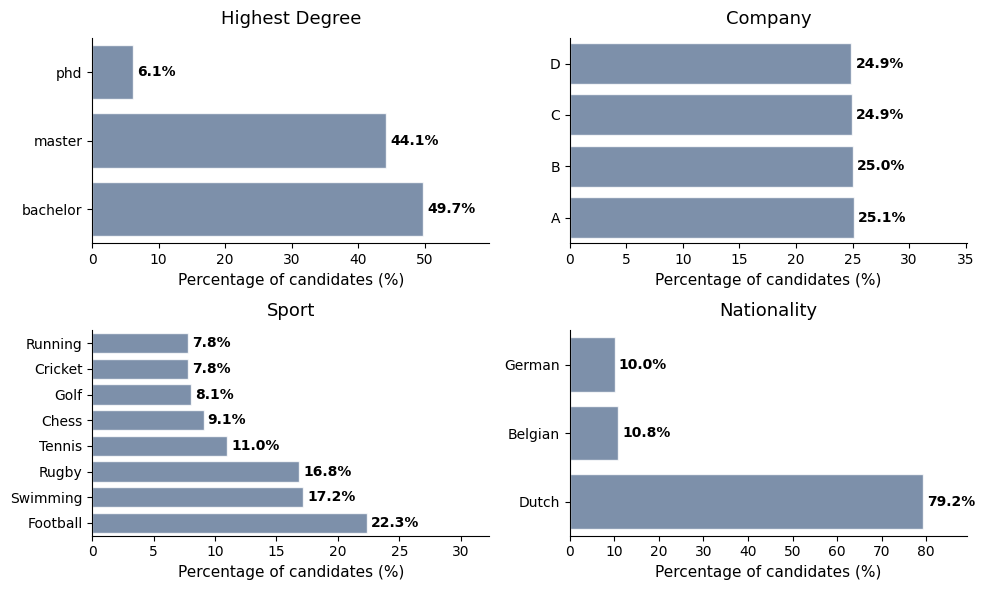

In [18]:
categorical_cols = {
    "ind-degree": "Highest Degree",
    "company": "Company",
    "sport": "Sport",
    "nationality": "Nationality"
}


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes = axes.ravel()
for ax, (col, title) in zip(axes, categorical_cols.items()):

    plot_df = (df[col].astype(str).value_counts(normalize=True).mul(100).reset_index())

    plot_df.columns = [col, "percentage"]
    plot_df = plot_df.sort_values("percentage", ascending=True)

    sns.barplot(data=plot_df,x="percentage",y=col,color="#53739E",edgecolor="white",ax=ax, alpha=0.8)

    for container in ax.containers:
        ax.bar_label(container,fmt="%.1f%%",padding=3,fontsize=10,fontweight="bold")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Percentage of candidates (%)", fontsize=11)
    ax.set_ylabel("")
    ax.set_xlim(0, plot_df["percentage"].max() + 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation between target and gender and other variables

In [12]:
label_map = {
    "ind-languages": "Languages",

    "age": "Age",

    "ind-degree_phd": "PhD degree",
    "ind-degree_master": "Master degree",
    'ind-degree_bachelor': "Bachelor degree",

    "ind-debateclub": "Debate club",
    'ind-programming_exp': "Programming exp.",
    'ind-exact_study': "In STEM",
    "ind-entrepeneur_exp": "Entrepreneurship exp.",
    "ind-university_grade": "University grade",
    "ind-international_exp": "International exp.",
    
    'nationality_Belgian': "Belgian",
    'nationality_Dutch': "Dutch",
    'nationality_German': "German",

    'sport_Chess': "Chess",
    'sport_Cricket': "Cricket",
    'sport_Football': "Football",
    'sport_Golf': "Golf",
    'sport_Rugby': "Rugby",
    'sport_Running': "Running",
    'sport_Swimming': "Swimming",
    'sport_Tennis': "Tennis",

    'company_A': "Company A",
    "company_B": "Company B",
    "company_C": "Company C",
    "company_D": "Company D",

    'gender_male': "Male",
    "gender_female": "Female", 
    
    'decision': 'Decision'
    
}

data['decision'] = target

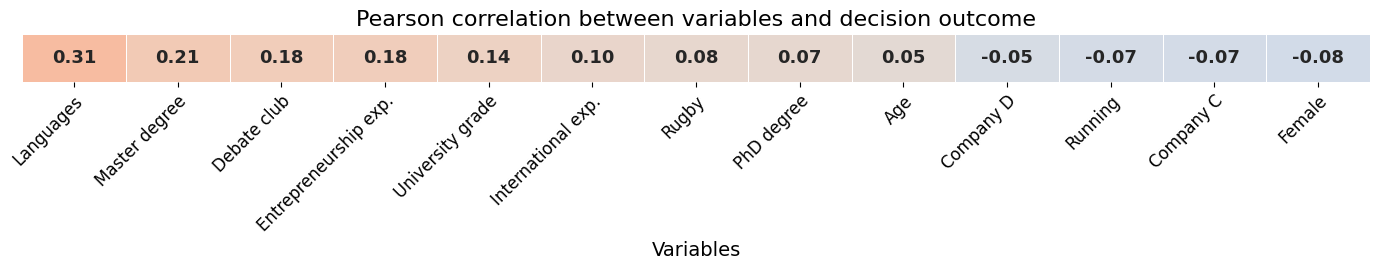

In [13]:
### Correlation Matrix for target
target_col = "decision"

y = data[target_col].astype(int)
X = data.drop(columns=[target_col])


alpha = 0.05
corrected_alpha = alpha / X.shape[1]  # Bonferroni correction

results = []

for col in X.columns:
    x = X[col].astype(int)
    r, p = pearsonr(x, y)
    results.append({
        "variable": col,
        "correlation": r,
        "p": p
    })

corr_target = pd.DataFrame(results)

##Filter to only plot significant correlations
significant_corrs_target = corr_target[corr_target["p"] < corrected_alpha]
significant_corrs_target = significant_corrs_target.sort_values("correlation", ascending=False)
corr_heatmap = significant_corrs_target.set_index("variable")[["correlation"]]

## Plot the heatmap of significant correlations
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(
    corr_heatmap.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5, 
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax
)

new_labels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]

ax.set_xticklabels(new_labels,rotation=45,ha="right",rotation_mode="anchor",fontsize=12)

plt.title("Pearson correlation between variables and decision outcome", fontsize=16,)
plt.xlabel("Variables", fontsize=14)
#plt.ylabel("Pearson")
ax.set_yticklabels([])  
ax.tick_params(left=False)  

plt.tight_layout()
plt.show()

In [14]:
### Correlation Matrix for target
target_col = "gender_male"

y = data[target_col].astype(int)
X = data.drop(columns=[target_col, 'gender_female'])


alpha = 0.05
corrected_alpha = alpha / X.shape[1]  # Bonferroni correction

results = []

for col in X.columns:
    x = X[col].astype(int)
    r, p = pearsonr(x, y)
    results.append({
        "variable": col,
        "correlation": r,
        "p": p
    })

corr_target = pd.DataFrame(results)

##Filter to only plot significant correlations
significant_corrs_gender = corr_target[corr_target["p"] < corrected_alpha]
significant_corrs_gender = significant_corrs_gender.sort_values("correlation", ascending=False)
corr_heatmap = significant_corrs_gender.set_index("variable")[["correlation"]]

## Plot the heatmap of significant correlations
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(
    corr_heatmap.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5, 
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax
)

new_labels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]

ax.set_xticklabels(new_labels,rotation=45,ha="right",rotation_mode="anchor",fontsize=12)

plt.title("Pearson correlation between variables and gender (Male)", fontsize=16,)
plt.xlabel("Variables", fontsize=14)
#plt.ylabel("Pearson")
ax.set_yticklabels([])  
ax.tick_params(left=False)  

plt.tight_layout()
plt.show()

KeyError: 'gender_male'

### Recruitment Outcome by Gender

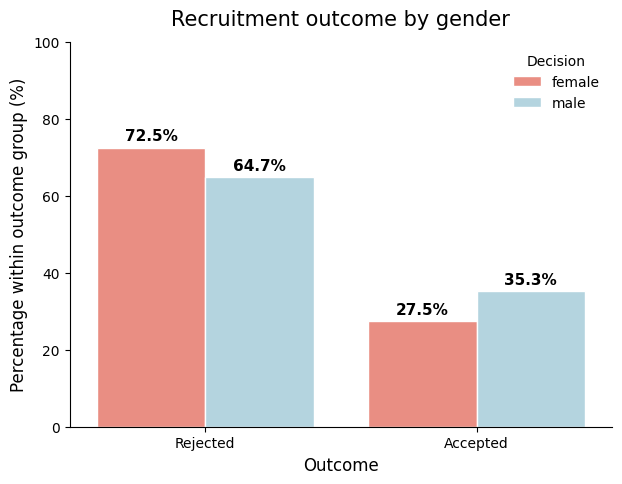

In [ ]:
# Count observations by gender and decision
plot_gender_decision_df = (df.groupby(["gender", "decision"]).size().reset_index(name="count"))

# Percentage
plot_gender_decision_df["percentage"] = (plot_gender_decision_df["count"] / plot_gender_decision_df.groupby("gender")["count"].transform("sum") * 100)

plot_gender_decision_df["decision_label"] = plot_gender_decision_df["decision"].map({False: "Rejected",True: "Accepted"})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=plot_gender_decision_df,
    x="decision_label",
    y="percentage",
    hue="gender",
    edgecolor="white", 
    palette={
        "female": "salmon",
        "male": "lightblue"
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Recruitment outcome by gender", fontsize=15, pad=12)
ax.set_xlabel("Outcome", fontsize=12)
ax.set_ylabel("Percentage within outcome group (%)", fontsize=12)
ax.set_ylim(0, 100)

##Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title="Decision", frameon=False)

plt.show()